# Assignment No1

In [57]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from amocatlas import read

from amoc_analysis import plotting
from amoc_analysis.spectra_filtering import analysis, filters, spectra

## Read and Filter the data

In [58]:
ds=read.wh41n()

Loading 1 Willis & Hobbs 41°N dataset(s):
  0. hobbs_willis_amoc41N_tseries.txt: Transport time series of Ekman volume, Northward geostrophc, Meridional Overturning volume and Meridional Overturning Heat



In [59]:
MOC=ds["MOC"]
filtred_MOC=filters.tukey_lowpass(ds["MOC"],12,True)

## Plot timeseries and histogram

In [60]:
plt.rcParams.update({"font.size":16})

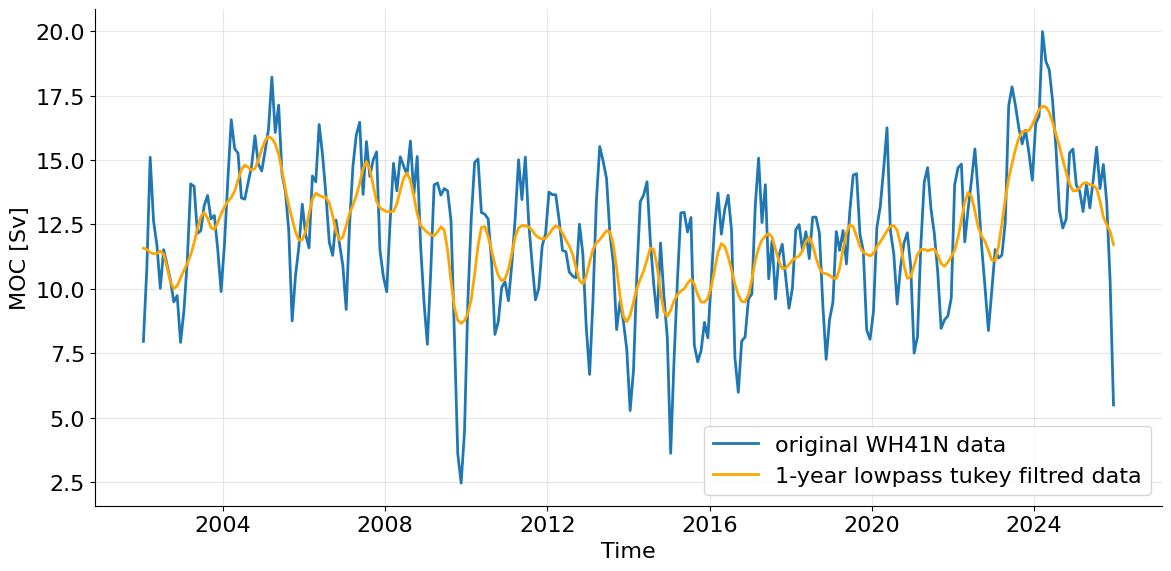

In [61]:
fig,ax=plotting.plot_time_series(ds,"MOC",label="original WH41N data", linewidth=2.0,color="tab:blue")

ax.plot(ds.TIME, filtred_MOC, color="orange", linewidth=2.0,label="1-year lowpass tukey filtred data")
ax.set_ylabel("MOC [Sv]")

plt.legend()

plt.title("")
plt.tight_layout()
plt.savefig(r"..\figures\wh41n_timeseries.png", bbox_inches="tight")

In [62]:
plt.rcParams.update({"font.size":10})

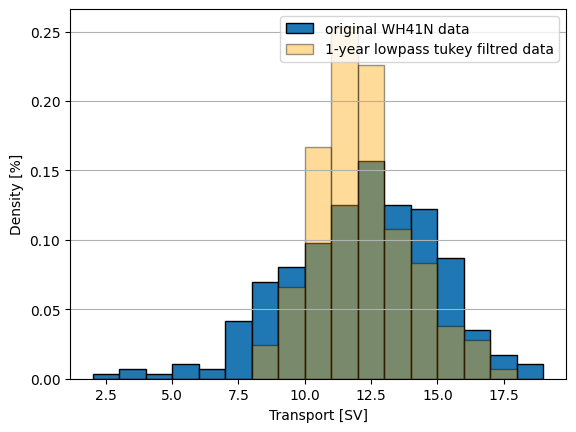

In [63]:
bins=np.arange(2,20,1)
plt.hist(MOC,bins=bins,density=True,histtype="bar",linestyle="-",edgecolor="black", label="original WH41N data", color="tab:blue")
plt.hist(filtred_MOC,bins=bins,density=True,histtype="bar",linestyle="-",alpha=0.4,color="orange",edgecolor="black",label="1-year lowpass tukey filtred data")
plt.xlabel("Transport [SV]")
plt.ylabel("Density [%]")
plt.legend()
plt.grid(axis="y")
plt.savefig(r"..\figures\histograms.png", bbox_inches="tight")


## Statistical values of MOC

In [64]:
analysis.summary_stats(MOC)

{'n': 288,
 'n_missing': 0,
 'mean': 12.135603915625,
 'std': 2.811908456102489,
 'median': 12.271187,
 'min': 2.4702439,
 'max': 19.97875,
 'range': 17.5085061}

In [65]:
analysis.summary_stats(filtred_MOC)

{'n': 288,
 'n_missing': 0,
 'mean': 12.149147545203602,
 'std': 1.763658277458475,
 'median': 11.977193729008132,
 'min': 8.665032164645845,
 'max': 17.08887203882533,
 'range': 8.423839874179484}

## Calculate and plot spectra

In [66]:
plt.rcParams.update({"font.size":10})

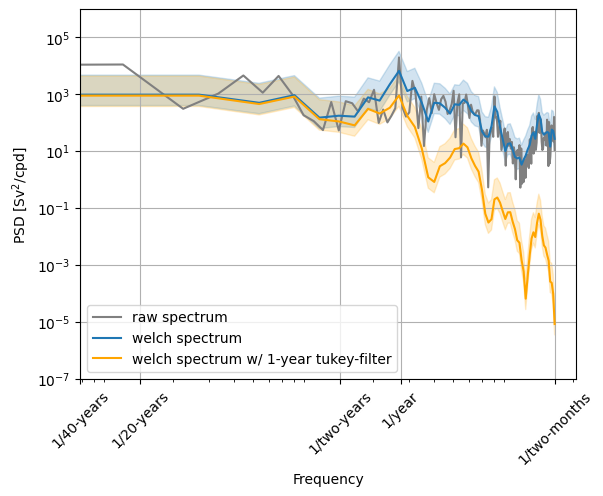

In [67]:
f,psd=spectra.raw_periodogram(MOC,31)
fw,psdw,lo,hi=spectra.welch_psd(MOC,31,120,confint=True)
fwf,psdwf,lof,hif=spectra.welch_psd(filtred_MOC,31,120,confint=True)

periods = {
        "1/day":    1 / 1,
        "1/week":   1 / 7,
        "1/month":  1 / 30,
        "1/year":   1 / 365,
    }


plt.loglog(f,psd,label="raw spectrum", c="grey")
plt.loglog(fw,psdw,label="welch spectrum",c="tab:blue")
plt.fill_between(fw,psdw*lo,psdw*hi,alpha=0.2,color="tab:blue")
plt.loglog(fwf,psdwf,label="welch spectrum w/ 1-year tukey-filter",c="orange")
plt.fill_between(fwf,psdwf*lof,psdwf*hif,alpha=0.2,color="orange")
plt.xticks([1/(40*365),1/(20*365),1/730, 1/365, 1/62,],["1/40-years","1/20-years","1/two-years","1/year", "1/two-months"],rotation=45)
plt.grid(True)
plt.xlabel("Frequency")
plt.ylabel("PSD [Sv$^2$/cpd]")
plt.ylim(10e-8)
plt.legend()
plt.savefig(r"..\figures\spectrum.png",bbox_inches="tight")
plt.show()


### parseval test

In [68]:
parseval_raw=spectra.parseval_ratio(MOC,f,psd)
parseval_welch=spectra.parseval_ratio(MOC,fw,psdw)
parseval_welch_f=spectra.parseval_ratio(filtred_MOC,fwf,psdwf)

print(parseval_raw)
print(parseval_welch)
print(parseval_welch_f)

0.9994873959424944
0.7653685097058819
0.40502939696770734


## Investigate filter

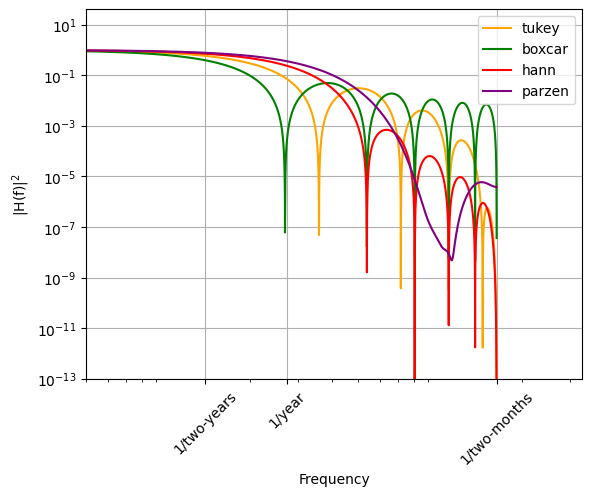

In [69]:
fig,ax=filters.window_frequency_response(12,31,("tukey","boxcar","hann","parzen"),)
ax.set_xticks([1/730, 1/365, 1/62,],)
ax.set_xticklabels(["1/two-years","1/year", "1/two-months"],rotation=45)
ax.set_xlim(1/2000,1/30)
ax.set_ylim(10e-14)
ax.set_xlabel("Frequency")
ax.set_ylabel("|H(f)|$^2$")
ax.grid()
plt.savefig(r"..\figures\response.png",bbox_inches="tight")
plt.show()

In [70]:
plt.rcParams.update({"font.size":16})

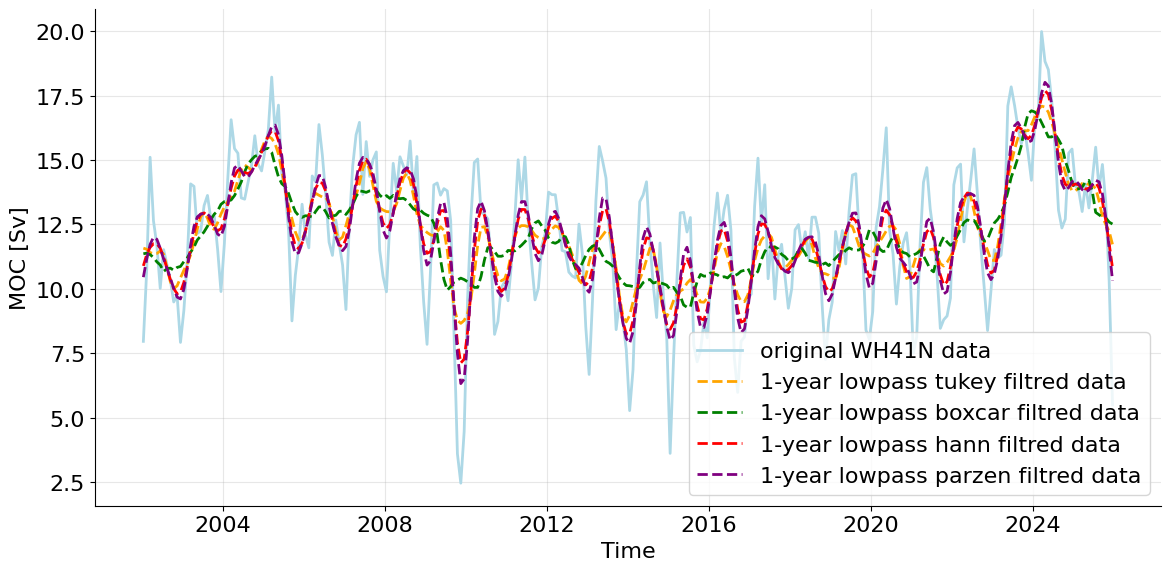

In [71]:
s = pd.Series(np.asarray(MOC, dtype="float64"))
boxcar_filtred_MOC=np.array(s.rolling(12, center=True, win_type="boxcar", min_periods=1).mean())
hann_filtred_MOC=np.array(s.rolling(12, center=True, win_type="hann", min_periods=1).mean())
parzen_filtred_MOC=np.array(s.rolling(12, center=True, win_type="parzen", min_periods=1).mean())
fig,ax=plotting.plot_time_series(ds,"MOC",label="original WH41N data",linewidth=2.0,color="lightblue")

ax.plot(ds.TIME, filtred_MOC, ls="--",color="orange", linewidth=2.0,label="1-year lowpass tukey filtred data")
ax.plot(ds.TIME, boxcar_filtred_MOC, "--g", linewidth=2.0,label="1-year lowpass boxcar filtred data")
ax.plot(ds.TIME, hann_filtred_MOC, "--r", linewidth=2.0,label="1-year lowpass hann filtred data")
ax.plot(ds.TIME, parzen_filtred_MOC, ls="--",color="purple", linewidth=2.0,label="1-year lowpass parzen filtred data")

plt.legend()

plt.title("")
plt.tight_layout()
plt.ylabel("MOC [Sv]")
plt.savefig(r"..\figures\timeseries_boxcar.png",bbox_inches="tight")
plt.show()


In [72]:
plt.rcParams.update({"font.size":10})

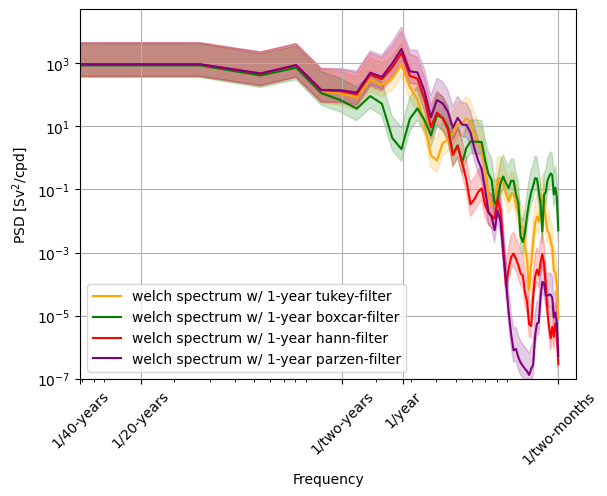

In [73]:
# f,psd=spectra.raw_periodogram(MOC,31)
# fw,psdw,lo,hi=spectra.welch_psd(MOC,31,120,confint=True)
fwf,psdwf,lof,hif=spectra.welch_psd(filtred_MOC,31,120,confint=True)
fwbf,psdwbf,lobf,hibf=spectra.welch_psd(np.array(boxcar_filtred_MOC),31,120,confint=True)
fwhf,psdwhf,lohf,hihf=spectra.welch_psd(np.array(hann_filtred_MOC),31,120,confint=True)
fwpf,psdwpf,lopf,hipf=spectra.welch_psd(np.array(parzen_filtred_MOC),31,120,confint=True)

periods = {
        "1/day":    1 / 1,
        "1/week":   1 / 7,
        "1/month":  1 / 30,
        "1/year":   1 / 365,
    }


#plt.loglog(f,psd,label="raw spectrum", c="grey")
# plt.loglog(fw,psdw,label="welch spectrum",c="blue")
# plt.fill_between(fw,psdw*lo,psdw*hi,alpha=0.2,color="blue")
plt.loglog(fwf,psdwf,label="welch spectrum w/ 1-year tukey-filter",c="orange")
plt.fill_between(fwf,psdwf*lof,psdwf*hif,alpha=0.2,color="orange")
plt.loglog(fwbf,psdwbf,label="welch spectrum w/ 1-year boxcar-filter",c="green")
plt.fill_between(fwbf,psdwbf*lobf,psdwbf*hibf,alpha=0.2,color="green")
plt.loglog(fwhf,psdwhf,label="welch spectrum w/ 1-year hann-filter",c="red")
plt.fill_between(fwhf,psdwhf*lohf,psdwhf*hihf,alpha=0.2,color="red")
plt.loglog(fwpf,psdwpf,label="welch spectrum w/ 1-year parzen-filter",c="purple")
plt.fill_between(fwpf,psdwpf*lopf,psdwpf*hipf,alpha=0.2,color="purple")
plt.xticks([1/(40*365),1/(20*365),1/730, 1/365, 1/62,],["1/40-years","1/20-years","1/two-years","1/year", "1/two-months"],rotation=45)
plt.grid(True)
plt.xlabel("Frequency")
plt.ylabel("PSD [Sv$^2$/cpd]")
plt.ylim(10e-8)
plt.legend()
plt.savefig(r"..\figures\spectrum_boxcar.png",bbox_inches="tight")